### Requires the scenicplus conda environmental

In [1]:
import os
import mudata
import pickle
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import upsetplot
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)
from collections import Counter
import anndata

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
%%time
cto_path = "pycistopic_outs/updated_cistopic_obj.pkl"
with open(cto_path, 'rb') as file:
    cto = pickle.load(file)

CPU times: user 688 ms, sys: 1.4 s, total: 2.09 s
Wall time: 3.58 s


In [4]:
Counter(cto.cell_data.updated_cell_type)

Counter({'Cardiomyocyte:female:middle': 834,
         'Cardiomyocyte:female:old': 834,
         'Endothelial:female:middle': 834,
         'Endothelial:female:old': 834,
         'Fibroblast:female:middle': 834,
         'Fibroblast:female:old': 834,
         'Myeloid:female:middle': 834,
         'Myeloid:female:old': 834,
         'Pericyte:female:middle': 834,
         'Pericyte:female:old': 834,
         'Cardiomyocyte:female:young': 833,
         'Cardiomyocyte:male:middle': 833,
         'Cardiomyocyte:male:old': 833,
         'Cardiomyocyte:male:young': 833,
         'Endothelial:female:young': 833,
         'Endothelial:male:middle': 833,
         'Endothelial:male:old': 833,
         'Endothelial:male:young': 833,
         'Fibroblast:female:young': 833,
         'Fibroblast:male:middle': 833,
         'Fibroblast:male:old': 833,
         'Fibroblast:male:young': 833,
         'Myeloid:female:young': 833,
         'Myeloid:male:middle': 833,
         'Myeloid:male:old': 833,
 

In [5]:
%%time
adata = sc.read_h5ad("03_RNA_adata_for_scenicplus.h5ad")

CPU times: user 144 ms, sys: 433 ms, total: 577 ms
Wall time: 575 ms


In [6]:
adata.obs.updated_cell_type

ENCSR755CIF:ACCACACCATTCCTCG    Cardiomyocyte:female:middle
ENCSR398YBK:TAACCGGTCGTTACAA    Cardiomyocyte:female:middle
ENCSR190TRK:ACATTAGTCATGCTTT    Cardiomyocyte:female:middle
P1582:AGTAACCTCCACCCTA-1-60     Cardiomyocyte:female:middle
H0020_LV:ATACCGAAGAGAGCGG       Cardiomyocyte:female:middle
                                           ...             
ReichartH46:773447                      Pericyte:male:young
ENCSR814LMX:GCATTGCCAGCAACAG            Pericyte:male:young
ENCSR084XKX:TTGCAATCATCAGTAT            Pericyte:male:young
ENCSR439ZVQ:CCGTTACTCCTCCATA            Pericyte:male:young
TWCM-13-198:GGACATTAGAAGATTC            Pericyte:male:young
Name: updated_cell_type, Length: 15000, dtype: category
Categories (30, object): ['Cardiomyocyte:female:middle', 'Cardiomyocyte:female:old', 'Cardiomyocyte:female:young', 'Cardiomyocyte:male:middle', ..., 'Pericyte:female:young', 'Pericyte:male:middle', 'Pericyte:male:old', 'Pericyte:male:young']

In [7]:
%%time
scplus_mdata = mudata.read("scplus_pipeline/Snakemake/scplusmdata.h5mu")

/home/william/.local/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)


CPU times: user 2.39 s, sys: 1min 27s, total: 1min 30s
Wall time: 1min 30s


/home/william/.local/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [8]:
scplus_mdata

MuData object with n_obs × n_vars = 30000 × 662086
  uns:	'direct_e_regulon_metadata', 'extended_e_regulon_metadata'
  6 modalities
    scRNA_counts:	30000 x 16115
      obs:	'updated_cell_type'
    scATAC_counts:	30000 x 645263
      obs:	'updated_cell_type'
      var:	'Chromosome', 'Start', 'End', 'Width', 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc'
    direct_gene_based_AUC:	30000 x 219
    direct_region_based_AUC:	30000 x 219
    extended_gene_based_AUC:	30000 x 135
    extended_region_based_AUC:	30000 x 135

In [9]:
scplus_mdata.mod['scRNA_counts'].obs

,updated_cell_type
Cardiomyocyte:female:middle_0,Cardiomyocyte:female:middle
Cardiomyocyte:female:middle_1,Cardiomyocyte:female:middle
Cardiomyocyte:female:middle_2,Cardiomyocyte:female:middle
Cardiomyocyte:female:middle_3,Cardiomyocyte:female:middle
Cardiomyocyte:female:middle_4,Cardiomyocyte:female:middle
...,...
Pericyte:male:young_995,Pericyte:male:young
Pericyte:male:young_996,Pericyte:male:young
Pericyte:male:young_997,Pericyte:male:young
Pericyte:male:young_998,Pericyte:male:young


In [10]:
Counter(scplus_mdata.mod['scRNA_counts'].obs.updated_cell_type)

Counter({'Cardiomyocyte:female:middle': 1000,
         'Cardiomyocyte:female:old': 1000,
         'Cardiomyocyte:female:young': 1000,
         'Cardiomyocyte:male:middle': 1000,
         'Cardiomyocyte:male:old': 1000,
         'Cardiomyocyte:male:young': 1000,
         'Endothelial:female:middle': 1000,
         'Endothelial:female:old': 1000,
         'Endothelial:female:young': 1000,
         'Endothelial:male:middle': 1000,
         'Endothelial:male:old': 1000,
         'Endothelial:male:young': 1000,
         'Fibroblast:female:middle': 1000,
         'Fibroblast:female:old': 1000,
         'Fibroblast:female:young': 1000,
         'Fibroblast:male:middle': 1000,
         'Fibroblast:male:old': 1000,
         'Fibroblast:male:young': 1000,
         'Myeloid:female:middle': 1000,
         'Myeloid:female:old': 1000,
         'Myeloid:female:young': 1000,
         'Myeloid:male:middle': 1000,
         'Myeloid:male:old': 1000,
         'Myeloid:male:young': 1000,
         'Pericyte

In [11]:
#scplus_mdata.mod['scRNA_counts'].obs.cell_type = scplus_mdata.mod['scRNA_counts'].obs.index.str.rsplit('_', n=1).str[0]
#scplus_mdata.mod['scRNA_counts'].obs['cell_type_age'] = scplus_mdata.mod['scRNA_counts'].obs.index.str.rsplit('_', 1).str[0]

#### Direct and extended predicted TF-to-region-to-gene links. This dataframe contains also a ranking of each TF-region-gene triplet, based on its importance triplet_rank.

In [12]:
scplus_mdata.uns["direct_e_regulon_metadata"]

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr13:96223186-96223687,HS6ST3,0.140992,0.296832,0.041851,0.041851,AR,False,AR_direct_+/+,AR_direct_+/+_(49g),AR_direct_+/+_(52r),1.071247,1,0.144793,1209
1,chr10:114628990-114629491,ABLIM1,0.000249,0.676631,0.000169,0.000169,AR,False,AR_direct_+/+,AR_direct_+/+_(49g),AR_direct_+/+_(52r),1.887564,1,0.229860,21505
2,chr1:40651357-40651858,ZNF684,0.089838,0.235620,0.021168,0.021168,AR,False,AR_direct_+/+,AR_direct_+/+_(49g),AR_direct_+/+_(52r),0.546045,1,0.087005,10958
3,chr9:109313917-109314418,EPB41L4B,0.006028,0.404216,0.002437,0.002437,AR,False,AR_direct_+/+,AR_direct_+/+_(49g),AR_direct_+/+_(52r),1.063163,1,0.167502,24586
4,chr1:233700285-233700786,KCNK1,0.045600,0.342377,0.015612,0.015612,AR,False,AR_direct_+/+,AR_direct_+/+_(49g),AR_direct_+/+_(52r),0.561045,1,0.118582,19557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31644,chr18:9672640-9673141,RAB31,0.000351,-0.122510,-0.000043,0.000043,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(18g),ZEB1_direct_-/-_(19r),0.732072,-1,-0.190114,28635
31645,chr6:13419789-13420290,PHACTR1,0.000431,-0.137531,-0.000059,0.000059,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(18g),ZEB1_direct_-/-_(19r),1.240360,-1,-0.133740,29884
31646,chr11:47329926-47330427,SPI1,0.001041,-0.126235,-0.000131,0.000131,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(18g),ZEB1_direct_-/-_(19r),0.869272,-1,-0.168258,22964
31647,chr14:22983209-22983710,SLC7A8,0.001088,-0.050733,-0.000055,0.000055,ZEB1,False,ZEB1_direct_-/-,ZEB1_direct_-/-_(18g),ZEB1_direct_-/-_(19r),0.507911,-1,-0.129361,29798


In [13]:
direct_regulons = scplus_mdata.uns["direct_e_regulon_metadata"]

In [14]:
direct_regulons = scplus_mdata.uns["direct_e_regulon_metadata"].sort_values(by = "triplet_rank")
direct_regulons

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
7194,chr4:18075779-18076280,LCORL,0.233791,0.050245,0.011747,0.011747,FLI1,False,FLI1_direct_+/+,FLI1_direct_+/+_(419g),FLI1_direct_+/+_(1911r),2.689633,1,0.108092,0
6068,chr10:19815953-19816454,PLXDC2,0.101527,0.488183,0.049564,0.049564,FLI1,False,FLI1_direct_+/+,FLI1_direct_+/+_(419g),FLI1_direct_+/+_(1911r),24.098043,1,0.351413,1
19871,chr3:180601870-180602371,TTC14,0.156420,-0.050159,-0.007846,0.007846,ELF1,False,ELF1_direct_+/-,ELF1_direct_+/-_(355g),ELF1_direct_+/-_(773r),1.228077,1,0.071345,2
4985,chr5:159099647-159100148,EBF1,0.034969,0.593144,0.020742,0.020742,ETS1,False,ETS1_direct_+/+,ETS1_direct_+/+_(214g),ETS1_direct_+/+_(791r),1.149743,1,0.211367,3
12045,chr7:82319707-82320208,CACNA2D1,0.141198,0.543230,0.076703,0.076703,MEIS2,False,MEIS2_direct_+/+,MEIS2_direct_+/+_(335g),MEIS2_direct_+/+_(601r),14.224085,1,0.382168,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28744,chr10:51832929-51833430,PRKG1,0.000135,0.226639,0.000031,0.000031,ATF6,False,ATF6_direct_-/+,ATF6_direct_-/+_(10g),ATF6_direct_-/+_(23r),0.025137,-1,-0.125811,31644
31539,chr14:23320975-23321476,MYH7,0.004024,-0.056435,-0.000227,0.000227,SP3,False,SP3_direct_-/-,SP3_direct_-/-_(13g),SP3_direct_-/-_(37r),0.019297,-1,-0.050322,31645
30387,chr1:237770559-237771060,RYR2,0.000139,0.662900,0.000092,0.000092,SP3,False,SP3_direct_-/+,SP3_direct_-/+_(10g),SP3_direct_-/+_(20r),0.023736,-1,-0.068168,31646
31559,chr14:23562658-23563159,MYH7,0.001477,-0.085810,-0.000127,0.000127,SP3,False,SP3_direct_-/-,SP3_direct_-/-_(13g),SP3_direct_-/-_(37r),0.019297,-1,-0.050322,31647


In [15]:
direct_regulons.to_csv("04_SCENICplus_direct_regulons.csv")

In [16]:
extended_regulons = scplus_mdata.uns["extended_e_regulon_metadata"]
extended_regulons

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
0,chr10:23095266-23095767,MSRB2,0.116268,0.064311,0.007477,0.007477,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(11g),ACAA1_extended_+/+_(11r),1.192306,1,0.059247,1814
1,chr8:67028352-67028853,COPS5,0.065848,0.112910,0.007435,0.007435,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(11g),ACAA1_extended_+/+_(11r),1.605721,1,0.058233,2085
2,chr11:63938580-63939081,OTUB1,0.038213,0.051020,0.001950,0.001950,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(11g),ACAA1_extended_+/+_(11r),1.266348,1,0.053062,7008
3,chr15:34721799-34722300,ACTC1,0.042010,0.066791,0.002806,0.002806,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(11g),ACAA1_extended_+/+_(11r),3.121323,1,0.143569,1831
4,chr17:5097443-5097944,SPAG7,0.021541,0.095136,0.002049,0.002049,ACAA1,True,ACAA1_extended_+/+,ACAA1_extended_+/+_(11g),ACAA1_extended_+/+_(11r),1.255123,1,0.054124,9693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18662,chr5:41193727-41194228,PLCXD3,0.001104,-0.106427,-0.000117,0.000117,TCF4,True,TCF4_extended_-/-,TCF4_extended_-/-_(23g),TCF4_extended_-/-_(26r),5.925053,-1,-0.335559,8888
18663,chr11:47254809-47255310,MYBPC3,0.001106,-0.468040,-0.000518,0.000518,TCF4,True,TCF4_extended_-/-,TCF4_extended_-/-_(23g),TCF4_extended_-/-_(26r),7.789782,-1,-0.354627,5816
18664,chr4:30619573-30620074,PCDH7,0.002074,-0.121671,-0.000252,0.000252,TCF4,True,TCF4_extended_-/-,TCF4_extended_-/-_(23g),TCF4_extended_-/-_(26r),4.478365,-1,-0.315724,7855
18665,chr8:22642953-22643454,PEBP4,0.000172,-0.303311,-0.000052,0.000052,TCF4,True,TCF4_extended_-/-,TCF4_extended_-/-_(23g),TCF4_extended_-/-_(26r),1.623449,-1,-0.247473,15777


In [17]:
extended_regulons.to_csv("04_SCENICplus_extended_regulons.csv")

### Downstream analysis

#### eRegulon dimensionality reduction

The eRegulon enrichment scores can be used to perform dimensionality reductions

#### AUC calculations

In [18]:
eRegulon_gene_AUC = anndata.concat(
    [scplus_mdata["direct_gene_based_AUC"], scplus_mdata["extended_gene_based_AUC"]],
    axis = 1,
)

In [19]:
eRegulon_gene_AUC.obs = scplus_mdata.obs.loc[eRegulon_gene_AUC.obs_names]
#eRegulon_gene_AUC.obs = scplus_mdata.mod['scRNA_counts'].obs

In [20]:
eRegulon_gene_AUC.obs['updated_cell_type'] = eRegulon_gene_AUC.obs.index.str.rsplit('_', n=1).str[0]

In [21]:
Counter(eRegulon_gene_AUC.obs['updated_cell_type'])

Counter({'Cardiomyocyte:female:middle': 1000,
         'Cardiomyocyte:female:old': 1000,
         'Cardiomyocyte:female:young': 1000,
         'Cardiomyocyte:male:middle': 1000,
         'Cardiomyocyte:male:old': 1000,
         'Cardiomyocyte:male:young': 1000,
         'Endothelial:female:middle': 1000,
         'Endothelial:female:old': 1000,
         'Endothelial:female:young': 1000,
         'Endothelial:male:middle': 1000,
         'Endothelial:male:old': 1000,
         'Endothelial:male:young': 1000,
         'Fibroblast:female:middle': 1000,
         'Fibroblast:female:old': 1000,
         'Fibroblast:female:young': 1000,
         'Fibroblast:male:middle': 1000,
         'Fibroblast:male:old': 1000,
         'Fibroblast:male:young': 1000,
         'Myeloid:female:middle': 1000,
         'Myeloid:female:old': 1000,
         'Myeloid:female:young': 1000,
         'Myeloid:male:middle': 1000,
         'Myeloid:male:old': 1000,
         'Myeloid:male:young': 1000,
         'Pericyte

In [22]:
sc.pp.neighbors(eRegulon_gene_AUC, use_rep = "X")

In [23]:
%%time
sc.tl.umap(eRegulon_gene_AUC)

CPU times: user 29 s, sys: 58.9 s, total: 1min 27s
Wall time: 15.2 s


/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


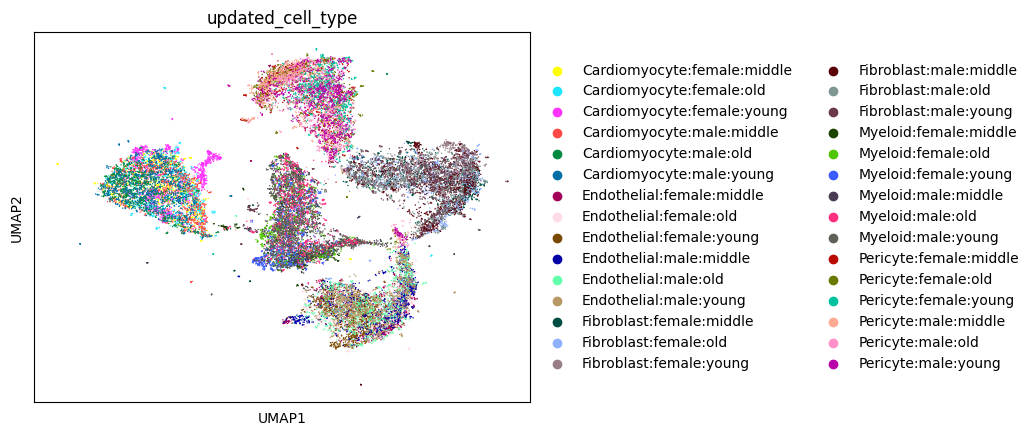

/home/william/anaconda3/envs/scenicplus/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


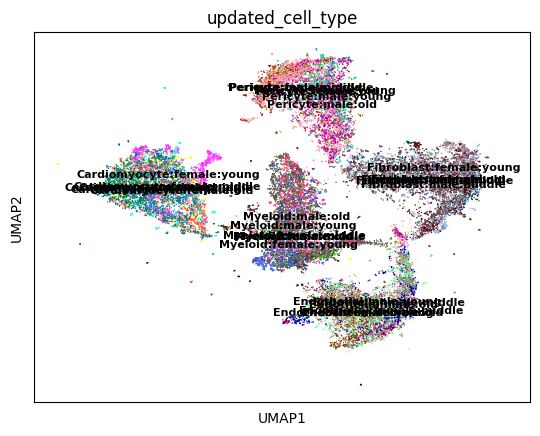

In [24]:
sc.pl.umap(eRegulon_gene_AUC, color = "updated_cell_type")
sc.pl.umap(eRegulon_gene_AUC, color = "updated_cell_type", legend_loc = "on data", legend_fontsize=8)

### eRegulon specificity score

In [25]:
rss = regulon_specificity_scores(
    scplus_mudata = scplus_mdata,
    variable = "scRNA_counts:updated_cell_type",
    modalities = ["direct_gene_based_AUC", "extended_gene_based_AUC"]
)

In [26]:
rss

,AHR_direct_+/-_(12g),AR_direct_+/+_(49g),ATF2_direct_+/+_(23g),ATF2_direct_+/-_(15g),ATF6_direct_+/+_(47g),ATF6_direct_+/-_(32g),ATF6_direct_-/+_(10g),BACH1_direct_+/+_(131g),BACH2_direct_+/+_(79g),BCL11A_direct_+/+_(233g),...,TBX20_extended_-/-_(14g),TBX2_extended_+/+_(15g),TBX5_extended_+/+_(86g),TBX5_extended_+/-_(11g),TCF12_extended_+/+_(24g),TCF4_extended_+/+_(54g),TCF4_extended_-/+_(29g),TCF4_extended_-/-_(23g),TWIST2_extended_+/+_(50g),ZNF462_extended_+/-_(11g)
Cardiomyocyte:female:middle,0.193958,0.274018,0.212301,0.218152,0.204810,0.190408,0.234256,0.213915,0.219367,0.273867,...,0.182978,0.237805,0.279038,0.277165,0.210514,0.187394,0.287478,0.285219,0.176177,0.245054
Cardiomyocyte:female:old,0.197496,0.271666,0.213845,0.215851,0.205334,0.189470,0.233707,0.213649,0.218456,0.272114,...,0.181280,0.236508,0.277400,0.273559,0.208846,0.186815,0.286105,0.286590,0.178533,0.238029
Cardiomyocyte:female:young,0.192097,0.279477,0.218010,0.221598,0.204271,0.190737,0.237661,0.215637,0.219876,0.276676,...,0.183680,0.238699,0.284979,0.283641,0.216690,0.185998,0.293610,0.287889,0.174821,0.233313
Cardiomyocyte:male:middle,0.196342,0.272917,0.214040,0.216335,0.205601,0.191196,0.233579,0.214499,0.218399,0.271852,...,0.181914,0.235451,0.277042,0.273897,0.211251,0.187892,0.285020,0.286249,0.176516,0.243018
Cardiomyocyte:male:old,0.187773,0.277947,0.215202,0.217475,0.204545,0.188722,0.237443,0.214458,0.220866,0.275387,...,0.182982,0.237590,0.282012,0.280026,0.209861,0.186107,0.290055,0.291123,0.174379,0.239976
Cardiomyocyte:male:young,0.186285,0.277171,0.215880,0.220399,0.205287,0.191371,0.236575,0.214598,0.219712,0.274260,...,0.185057,0.238555,0.279862,0.279796,0.212694,0.187431,0.287746,0.288720,0.177259,0.244246
Endothelial:female:middle,0.206394,0.189426,0.208856,0.211182,0.210780,0.211775,0.189223,0.207440,0.199744,0.190764,...,0.216448,0.186086,0.186836,0.179787,0.215363,0.230221,0.184377,0.179528,0.192319,0.197839
Endothelial:female:old,0.204056,0.190706,0.210830,0.207330,0.211875,0.212393,0.192643,0.206908,0.200836,0.189986,...,0.218058,0.188175,0.186868,0.177896,0.215309,0.230920,0.185003,0.181502,0.190984,0.194961
Endothelial:female:young,0.203761,0.191583,0.212389,0.212555,0.210578,0.212241,0.196859,0.207020,0.203392,0.193090,...,0.223212,0.187036,0.191072,0.176532,0.219328,0.234915,0.185535,0.183065,0.192881,0.192159
Endothelial:male:middle,0.204554,0.190081,0.208653,0.205571,0.207254,0.206585,0.189177,0.202856,0.197956,0.191157,...,0.214431,0.186494,0.188164,0.186019,0.208429,0.224012,0.185991,0.182812,0.191128,0.195712


#### Obtain the AUC and save as df

In [27]:
eRegulon_gene_AUC_df = pd.DataFrame(eRegulon_gene_AUC.X)
eRegulon_gene_AUC_df.index = eRegulon_gene_AUC.obs_names
eRegulon_gene_AUC_df.columns = eRegulon_gene_AUC.var_names

In [28]:
eRegulon_gene_AUC_df.to_csv("04A_regulon_AUC_df.csv")

### Produce plot of the each cell-type (sex + age group)

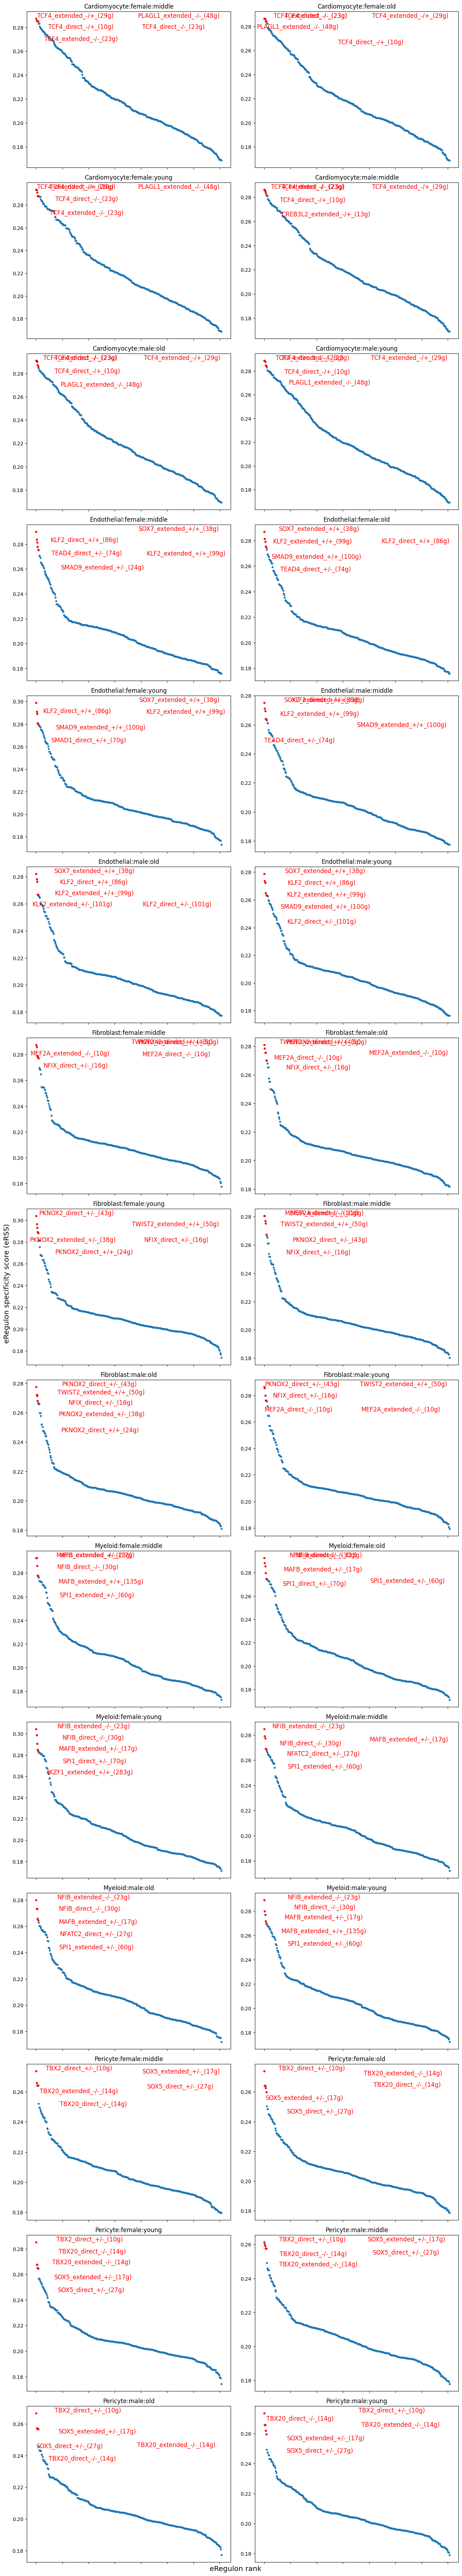

In [29]:
plot_rss(
    data_matrix = rss,
    top_n = 5,
    num_columns = 2
)

In [30]:
from scenicplus.plotting.dotplot import heatmap_dotplot

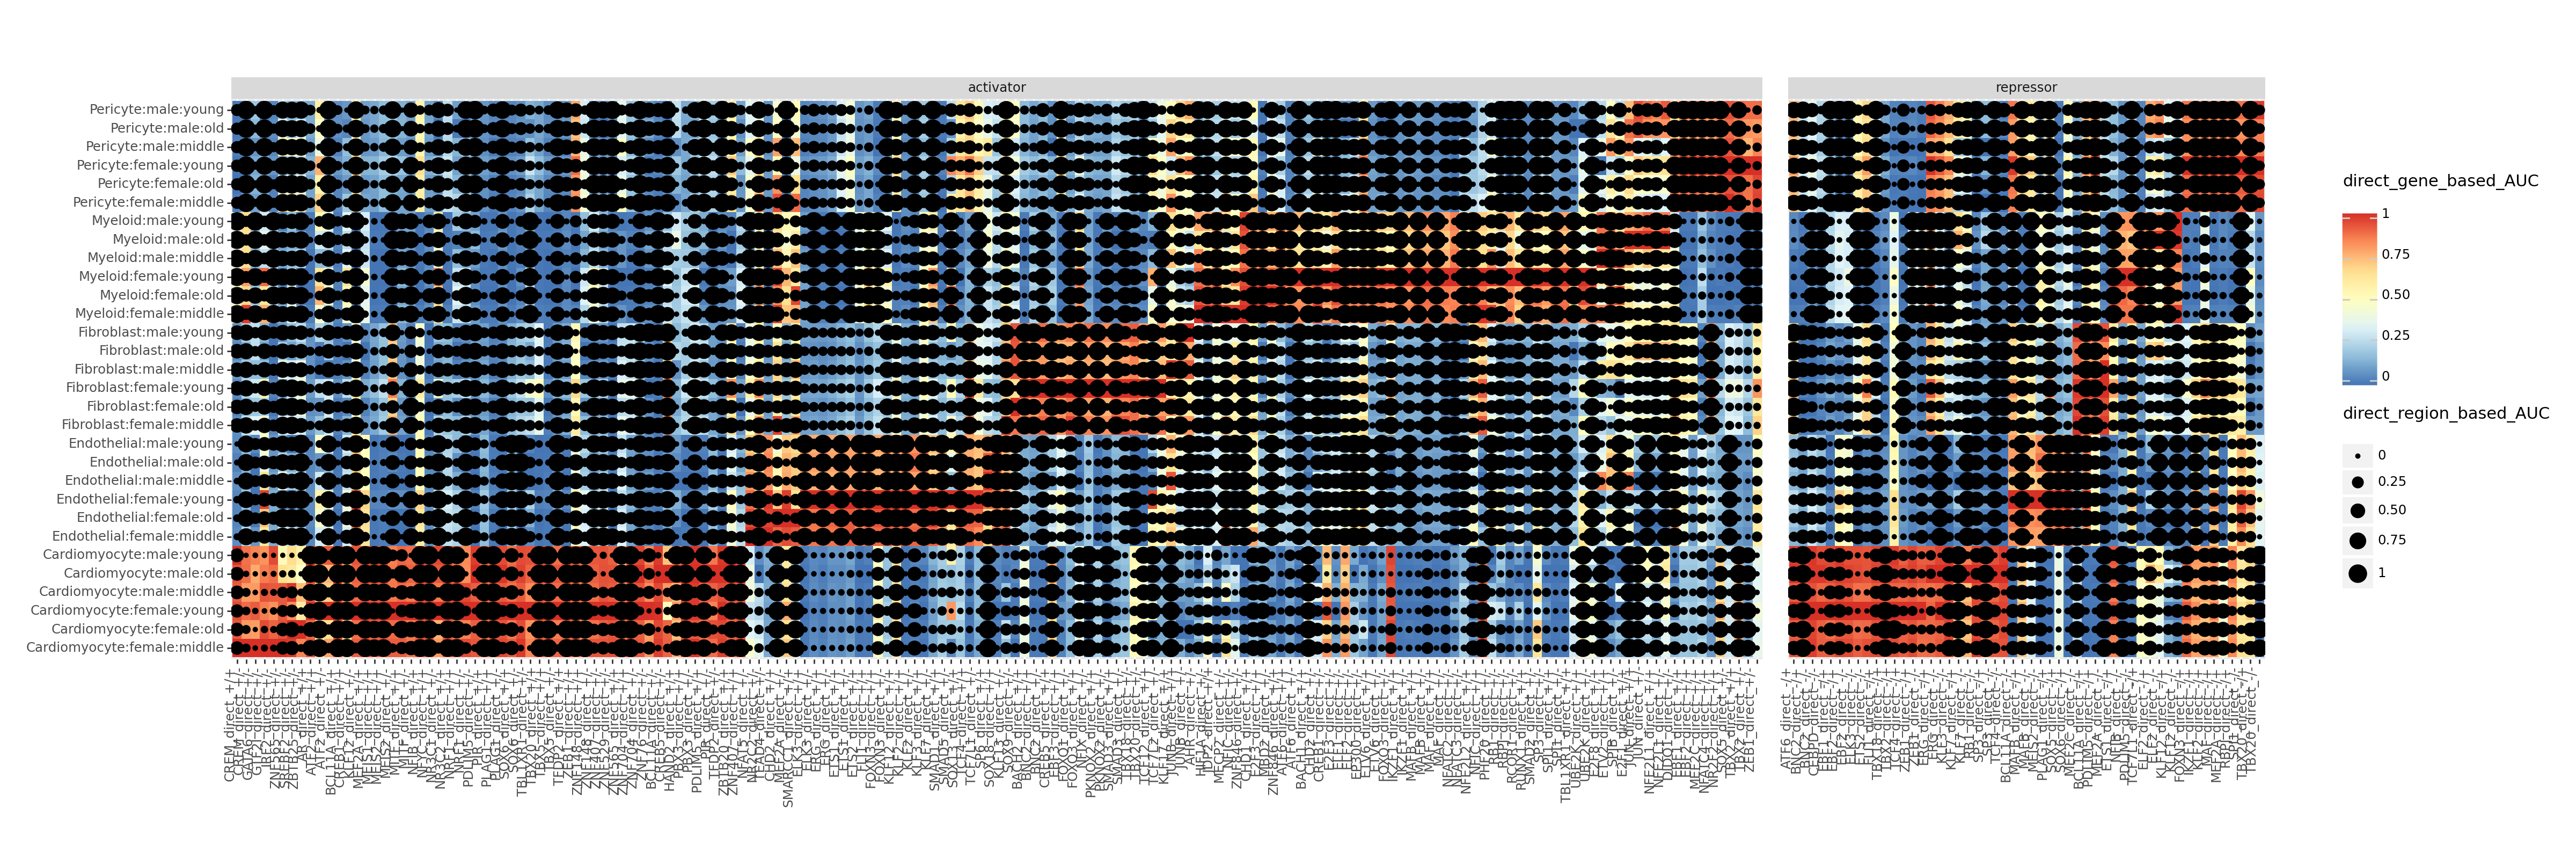

<Figure Size: (2400 x 800)>

In [31]:
heatmap_dotplot(
    scplus_mudata = scplus_mdata,
    color_modality = "direct_gene_based_AUC",
    size_modality = "direct_region_based_AUC",
    group_variable = "scRNA_counts:updated_cell_type",
    eRegulon_metadata_key = "direct_e_regulon_metadata",
    color_feature_key = "Gene_signature_name",
    size_feature_key = "Region_signature_name",
    feature_name_key = "eRegulon_name",
    sort_data_by = "direct_gene_based_AUC",
    orientation = "horizontal",
    figsize = (24, 8)
)